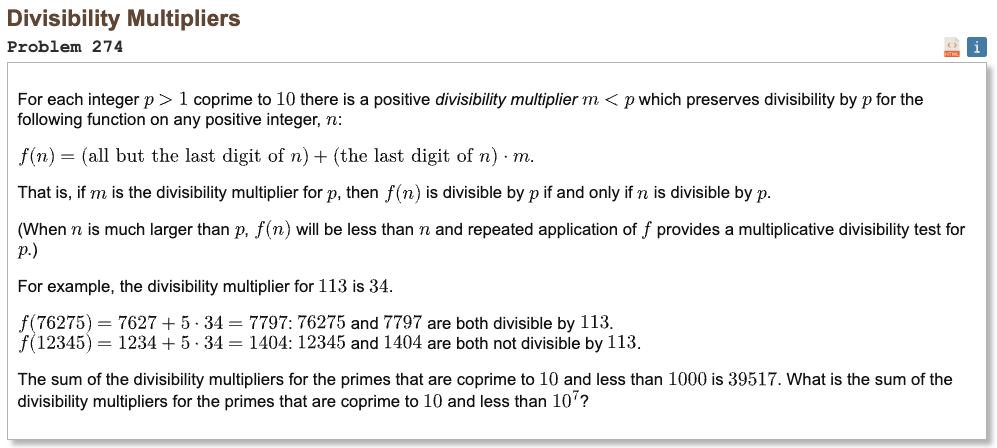

## Initial approach

* split the number into two parts: everything except the last digit, and the last digit itself
* we want a rule that lets us replace the original number with a much smaller one, while keeping the same divisibility result for p
* that means we need some fixed multiplier for the last digit, so that combining it with the rest of the number still tells us correctly whether p divides the original number
* for each prime p, that multiplier is the number which cancels the effect of the final decimal digit position when working modulo p
* once you have that multiplier, you can compute it for every prime below 10^7, ignoring 2 and 5 because base 10 causes special cases there
* then just add all those multipliers together
* in Python, pow(10, -1, p) gives exactly the multiplier we need
* so the main task is not the math itself, but generating all primes below 10^7 efficiently, and a bytearray sieve is fast enough for that

In [1]:
%%time
LIMIT = 10_000_000

is_prime = bytearray(b"\x01") * LIMIT
is_prime[0:2] = b"\x00\x00"

i = 2
while i * i < LIMIT:
    if is_prime[i]:
        start = i * i
        step = i
        is_prime[start:LIMIT:step] = b"\x00" * (((LIMIT - 1 - start) // step) + 1)
    i += 1

result = 0

for p in range(3, LIMIT):
    if is_prime[p] and p != 5:
        result += pow(10, -1, p)

print("Result:", result)

Result: 1601912348822
CPU times: user 476 ms, sys: 9.93 ms, total: 486 ms
Wall time: 485 ms
